<a href="https://colab.research.google.com/github/milvus-io/bootcamp/blob/master/integration/evaluation_with_deepeval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>   <a href="https://github.com/milvus-io/bootcamp/blob/master/integration/evaluation_with_deepeval.ipynb" target="_blank">
    <img src="https://img.shields.io/badge/View%20on%20GitHub-555555?style=flat&logo=github&logoColor=white" alt="GitHub Repository"/>
</a>


# Evaluation with DeepEval

This guide demonstrates how to use [DeepEval](https://docs.confident-ai.com/) to evaluate a Retrieval-Augmented Generation (RAG) pipeline built upon [Milvus](https://milvus.io/).

The RAG system combines a retrieval system with a generative model to generate new text based on a given prompt. The system first retrieves relevant documents from a corpus using Milvus, and then uses a generative model to generate new text based on the retrieved documents.

DeepEval is a framework that helps you evaluate your RAG pipelines. There are existing tools and frameworks that help you build these pipelines but evaluating it and quantifying your pipeline performance can be hard. This is where DeepEval comes in.

In [1]:
import sys
import os
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Add notebooks directory to Python path
notebooks_dir = Path.cwd()
if str(notebooks_dir) not in sys.path:
    sys.path.insert(0, str(notebooks_dir))

# Import with reload support
import importlib
import robust_evaluation_helpers
importlib.reload(robust_evaluation_helpers)
from robust_evaluation_helpers import process_questions_robust, process_retrieval_robust

print("✅ Robust evaluation helpers loaded (with reload)")
print(f"Project root: {project_root}")
print(f"Python path: {sys.path[0]}")

✅ Robust evaluation helpers loaded (with reload)
Project root: /Users/duykhangh/Work/HCMUT/thesis-llms-multilayer-graph
Python path: /Users/duykhangh/Work/HCMUT/thesis-llms-multilayer-graph/notebooks


We will use OpenAI as the LLM in this example. You should prepare the [api key](https://platform.openai.com/docs/quickstart) `CHAT_OPENAI_API_KEY` as an environment variable.

In [35]:
# Load environment variables
from dotenv import load_dotenv

env_file = project_root / ".env"
if env_file.exists():
    load_dotenv(env_file, override=True)
    print("✓ Environment variables loaded")
else:
    print("⚠ No .env file found")

# Verify required environment variables
required_vars = ["NEO4J_URI", "NEO4J_USERNAME", "NEO4J_PASSWORD", "GOOGLE_API_KEY", "CHAT_OPENAI_API_KEY"]
missing = [var for var in required_vars if not os.getenv(var)]

if missing:
    print(f"❌ Missing environment variables: {missing}")
else:
    print(f"✓ All required environment variables present")
    print(f"  - Neo4j URI: {os.getenv('NEO4J_URI')}")
    print(f"  - Neo4j Database: {os.getenv('NEO4J_DATABASE', 'neo4j')}")
    print(f"  - Embedding Model: {os.getenv('EMBEDDING_MODEL', 'gemini-embedding-001')}")

✓ Environment variables loaded
✓ All required environment variables present
  - Neo4j URI: bolt://localhost:7687
  - Neo4j Database: financebench1
  - Embedding Model: gemini-embedding-001


## Define the RAG pipeline

We will define the RAG class that use Milvus as the vector store, and OpenAI as the LLM.
The class contains the `load` method, which loads the text data into Milvus, the `retrieve` method, which retrieves the most similar text data to the given question, and the `answer` method, which answers the given question with the retrieved knowledge.

In [36]:
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
from langchain_openai import ChatOpenAI
from chatbot_graphs import build_graph, get_retriever
from typing import List
import os


class MultilayerGraphRAG:
    """
    Multilayer Graph RAG (Retrieval-Augmented Generation) class built upon Neo4j SPG Knowledge Graph.
    
    This wraps the SPG-based RAG system using vector similarity search for evaluation with DeepEval.
    Uses vector similarity on entity embeddings with full relationship properties.
    """

    def __init__(self):
        """Initialize the Multilayer Graph RAG system with Neo4j backend."""
        print("[MultilayerGraphRAG] Initializing Neo4j-based SPG Graph RAG...")
        
        # Initialize the graph and retriever
        self.graph = build_graph()
        self.retriever = get_retriever()
        
        # Initialize LLM with same config as agent
        self._init_llm()
        
        print("[MultilayerGraphRAG] Multilayer Graph RAG initialized successfully")
        print("[MultilayerGraphRAG] Using vector similarity search on SPG entities")

    def _init_llm(self):
        """Initialize LLM with same configuration as the agent."""
        base_url = os.getenv("CHAT_OPENAI_BASE_URL")
        api_key = os.getenv("CHAT_OPENAI_API_KEY")

        # If using custom base_url without api_key, use "EMPTY" as recommended by LangChain
        if base_url and not api_key:
            api_key = "EMPTY"

        llm_kwargs = {
            "model": os.getenv("CHAT_LLM_MODEL", "gpt-4o-mini"),
            "temperature": float(os.getenv("LLM_TEMPERATURE", "0.1")),
            "api_key": api_key,
        }

        # Add base_url if provided
        if base_url:
            llm_kwargs["base_url"] = base_url

            # Add headers to help bypass Cloudflare protection
            llm_kwargs["default_headers"] = {
                "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36",
                "Accept": "application/json",
                "Accept-Language": "en-US,en;q=0.9"
            }

        self.llm = ChatOpenAI(**llm_kwargs)
        print(f"[MultilayerGraphRAG] LLM initialized: {llm_kwargs['model']}")

    def retrieve(self, question: str, top_k: int = 5) -> List[str]:
        """
        Retrieve relevant information using vector similarity search on entity embeddings.
        
        This method uses semantic vector search on entities in the knowledge graph,
        then retrieves their relationships with full SPG property values and source chunks.
        
        Args:
            question: Query question
            top_k: Maximum number of context items to retrieve
            
        Returns:
            List of retrieved context strings with entities, relationships, and properties
        """
        print(f"\n[MultilayerGraphRAG] Processing question: {question[:80]}...")

        pre_process = f"""You are a financial analyst assistant. Your mission is to extract the key information needed to query the knowledge graph in order to find relevant data for answering the user's question.

Question: {question}

Example:
Question: Assume that you are a public equities analyst. Answer the following question by primarily using information shown in the balance sheet: what is the year-end FY2018 net PPNE for 3M? Answer in USD billions.

Answer: Consolidated Balance Sheet for FY2018 of 3M Company

Rule: 
1. Do not include your thinking, only the term of thing need to find.
2. Do not fabricate numbers or data; only return the names of entities or concepts that need to be found.
"""
        pre_process_question = self.llm.invoke([HumanMessage(content=pre_process)])

        query = pre_process_question.content

        print(f"\n[MultilayerGraphRAG.retrieve] Vector search for: {query}...")

        # Use vector similarity search method from retriever
        result = self.retriever.vector_similarity_search(
            query=query,
            limit=top_k,
            similarity_threshold=0.5
        )
        
        if not result or "No similar entities found" in result:
            return [f"No relevant information found in knowledge graph for: {question}"]
        
        # Split the formatted result into individual context items
        # Each entity starts with a markdown heading like "**EntityName**"
        contexts = []
        current_context = []
        
        for line in result.split('\n'):
            # Check if this is a new entity (starts with ** and has entity name)
            if line.strip().startswith('**') and '**' in line[2:] and current_context:
                # Save the previous context
                contexts.append('\n'.join(current_context))
                current_context = [line]
            else:
                current_context.append(line)
        
        # Add the last context
        if current_context:
            contexts.append('\n'.join(current_context))
        
        # Clean up empty contexts
        contexts = [ctx.strip() for ctx in contexts if ctx.strip()]
        
        if not contexts:
            return [result]  # Return as single context if splitting failed
        
        print(f"[MultilayerGraphRAG.retrieve] Returning {len(contexts)} entity contexts with relationships\n")
        return contexts[:top_k]

    def load(self, texts: List[str]):
        """
        Load text data into Neo4j knowledge graph.
        
        Note: This assumes you have already processed and loaded your data into Neo4j
        using the knowledge graph pipeline. This method is kept for interface compatibility
        but doesn't perform the actual loading.
        
        Args:
            texts: List of text documents (not used as data is pre-loaded in Neo4j)
        """
        print(f"[MultilayerGraphRAG] Note: Multilayer Graph RAG uses pre-loaded Neo4j SPG knowledge graph.")
        print(f"[MultilayerGraphRAG] Skipping load of {len(texts)} texts - ensure your Neo4j database is populated.")
        print(f"[MultilayerGraphRAG] Use the SPG pipeline to process and load documents into Neo4j.")

    def answer(
        self,
        question: str,
        retrieval_top_k: int = 10,
        return_retrieved_text: bool = False,
    ):
        """
        Answer a question using direct LLM invocation with retrieved context.

        This method:
        1. Retrieves relevant contexts using vector similarity search
        2. Directly invokes the LLM with the question and contexts
        3. Returns the generated answer

        Args:
            question: Question to answer
            retrieval_top_k: Number of context items to retrieve
            return_retrieved_text: Whether to return retrieved contexts along with answer

        Returns:
            Answer string, or tuple of (answer, contexts) if return_retrieved_text=True
        """
        # Retrieve contexts using vector search
        contexts = self.retrieve(question, retrieval_top_k)

        # Format contexts for the prompt
        context_str = "\n\n".join([f"Context {i+1}:\n{ctx}" for i, ctx in enumerate(contexts)])

        print(context_str)

        # Create prompt with question and contexts
        prompt = f"""You are a financial analyst assistant. Answer the question using only the provided contexts from the knowledge graph.

Contexts:
{context_str}

Question: {question}

Instructions:
1. Extract relevant financial data (numbers, percentages, dates, metrics) from the contexts
2. Perform any necessary calculations or comparisons if the question requires it
3. Provide a direct, concise answer that addresses what the user is asking
4. Focus on the key finding - avoid unnecessary background or explanations
5. If calculations are needed, show brief working (e.g., "$X - $Y = $Z")
6. If the contexts lack sufficient data to answer, state this clearly but returning which data is missing.

Answer:"""

        # Invoke LLM directly
        response = self.llm.invoke([HumanMessage(content=prompt)])
        answer = response.content

        print(f"[MultilayerGraphRAG] Generated answer using direct LLM invocation\n")

        if return_retrieved_text:
            return answer, contexts

        return answer

    def answer_with_graph_context(
        self,
        question: str,
        return_retrieved_text: bool = False,
    ):
        """
        Answer a question and extract the actual retrieved contexts from tool calls.
        
        This method inspects the agent's tool calls to get the actual retrieved contexts
        used during reasoning, providing more accurate evaluation data.
        
        Args:
            question: Question to answer
            return_retrieved_text: Whether to return retrieved contexts
            
        Returns:
            Answer string, or tuple of (answer, contexts) if return_retrieved_text=True
        """
        # Create initial state
        initial_state = {
            "messages": [HumanMessage(content=question)],
            "retrieved_context": "",
            "intent": "",
            "original_question": "",
            "entities": []
        }
        
        # Run the graph
        print(f"\n[MultilayerGraphRAG] Processing question: {question[:80]}...")
        result = self.graph.invoke(initial_state)
        
        # Extract answer and contexts from messages
        answer = None
        contexts = []
        
        for msg in result["messages"]:
            # Collect tool results (retrieved contexts)
            if isinstance(msg, ToolMessage):
                # Only include substantial tool results
                if len(msg.content) > 50 and "not found" not in msg.content.lower():
                    contexts.append(msg.content)
            
            # Get final answer
            elif isinstance(msg, AIMessage) and not msg.tool_calls:
                answer = msg.content
        
        if not answer:
            answer = "I couldn't generate an answer. Please try rephrasing your question."
        
        if not contexts:
            contexts = [f"No relevant context retrieved for: {question}"]
        
        if return_retrieved_text:
            return answer, contexts
        
        return answer

    def close(self):
        """Close the Neo4j connection."""
        if hasattr(self, 'retriever') and hasattr(self.retriever, 'driver'):
            self.retriever.driver.close()
            print("[MultilayerGraphRAG] Neo4j connection closed")

Let's initialize the RAG class with OpenAI and Milvus clients.

In [37]:
# Initialize MultilayerGraphRAG
# NOTE: Ensure your Neo4j database is running and populated with knowledge graph data
# The MultilayerGraphRAG system requires:
# 1. Neo4j database with populated SPG knowledge graph (entities, relationships, embeddings)
# 2. Environment variables set in .env file (NEO4J_URI, NEO4J_PASSWORD, GOOGLE_API_KEY, etc.)
# 3. OPENAI_API_KEY for the LLM agent

my_rag = MultilayerGraphRAG()

# Note: The load() method is no-op for MultilayerGraphRAG
# Data should be pre-loaded into Neo4j using the SPG knowledge graph pipeline
# Example:
# python run_server.py  # Start the server
# Use batch processing API endpoint to process documents into Neo4j
# See docs/BATCH_PROCESSING_GUIDE.md for details

[MultilayerGraphRAG] Initializing Neo4j-based SPG Graph RAG...

[Graph] Building RAG graph with ReAct agent...
[Graph] Flow: preprocess_query → agent (ReAct) → END
[MultilayerGraphRAG] LLM initialized: meta-llama/llama-3.2-3b-instruct
[MultilayerGraphRAG] Multilayer Graph RAG initialized successfully
[MultilayerGraphRAG] Using vector similarity search on SPG entities


Now let's prepare some questions with its corresponding ground truth answers. We get answers and contexts from our RAG pipeline.

In [38]:
# Import financebench dataset

import json
from datasets import Dataset
import pandas as pd
from tqdm import tqdm

data = []
with open("/Users/duykhangh/Work/HCMUT/thesis-llms-multilayer-graph/notebooks/financebench_open_source.jsonl", 'r') as f:
    for line in f:
        line = line.strip()
        if line:  # Skip empty lines
            data.append(json.loads(line))
financebench = pd.DataFrame(data)


In [39]:
# Preprocessing context ground truth
financebench["evidence_text"] = financebench["evidence"].apply(
    lambda x: " ".join([item["evidence_text"] for item in x]) if isinstance(x, list) else ""
)

In [40]:
# Prepare data

question_list = []
ground_truth_list = []
contexts_list = []
retrieval_list = []
answer_list = []
for question, ground_truth, context in zip(financebench["question"], financebench["answer"], financebench["evidence_text"]):
    question_list.append(question)
    ground_truth_list.append(ground_truth)
    contexts_list.append(context)


In [41]:
print(f"Number of questions: {len(question_list)}")
print(f"Number of ground truths: {len(ground_truth_list)}")
print(f"Number of contexts: {len(contexts_list)}")

Number of questions: 150
Number of ground truths: 150
Number of contexts: 150


In [42]:
question_list[10]

"You are an investment banker and your only resource(s) to answer the following question is (are): the statement of financial position and the cash flow statement. Here's the question: what is the FY2015 operating cash flow ratio for Adobe? Operating cash flow ratio is defined as: cash from operations / total current liabilities. Round your answer to two decimal places."

## Retrieval for Contextual Evaluation

In [ ]:
my_rag.retrieve(question_list[10], 3)

In [ ]:
retrieval_list = []
for question in tqdm(question_list, desc="Answering questions"):
    retrieval = my_rag.retrieve(question, 5)
    retrieval_list.append(retrieval)
    # time.sleep(3)

financebench_eval_top5 = pd.DataFrame(
    {
        "question": question_list,
        "contexts": contexts_list,
        "retrieval": retrieval_list,
        "ground_truth": ground_truth_list,
    }
)
rag_results = Dataset.from_pandas(financebench_eval_top5)
financebench_eval_top5

## Retrieval with Robust Batch Processing (NEW)

Use this approach to process retrieval with automatic checkpointing and resume capability. If the process fails, just re-run the cell and it will continue from where it left off.

In [44]:
# Use robust retrieval batch processing with checkpoint support
import time
from datasets import Dataset
import pandas as pd

print("\n" + "="*70)
print("Starting Robust Retrieval (Retrieval Only)")
print("="*70 + "\n")

# Process retrieval with robust error handling and checkpointing
retrieval_list = process_retrieval_robust(
    my_rag=my_rag,
    question_list=question_list,
    top_k=3,                                          # Retrieve top 5 contexts
    checkpoint_file="financebench_retrieval_llama_3.2_3B_top3_progress.json",
    checkpoint_interval=5,                            # Save checkpoint every 5 questions
    request_delay=2,                                  # 2 seconds between successful requests
    max_retries=3                                     # Retry up to 3 times per question
)

# Create DataFrame with results
financebench_eval_top3 = pd.DataFrame({
    "question": question_list,
    "contexts": contexts_list,
    "retrieval": retrieval_list,
    "ground_truth": ground_truth_list,
})

# Create Dataset for DeepEval
rag_results = Dataset.from_pandas(financebench_eval_top3)

print(f"\n✅ DataFrame created with {len(financebench_eval_top3)} rows")
print(f"✅ Dataset created for DeepEval evaluation")

# Display first few rows
financebench_eval_top3.head()


Starting Robust Retrieval (Retrieval Only)

ℹ️  No checkpoint found at financebench_retrieval_llama_3.2_3B_top3_progress.json
   Starting from beginning

Starting retrieval with robust error handling
Total questions: 150
Starting from: 0
Remaining: 150
Top-k contexts: 3
Checkpoint: financebench_retrieval_llama_3.2_3B_top3_progress.json (saves every 5 questions)
Request delay: 2s between requests
Max retries: 3 per question



Retrieving contexts:   0%|          | 0/150 [00:00<?, ?it/s]


──────────────────────────────────────────────────────────────────────
Question 1/150
──────────────────────────────────────────────────────────────────────
Q: What is the FY2018 capital expenditure amount (in USD millions) for 3M? Give a r...

[MultilayerGraphRAG] Processing question: What is the FY2018 capital expenditure amount (in USD millions) for 3M? Give a r...

[MultilayerGraphRAG.retrieve] Vector search for: Capital expenditure...
[MultilayerGraphRAG.retrieve] Returning 3 entity contexts with relationships

✅ Retrieved 3 contexts


Retrieving contexts:   1%|          | 1/150 [00:04<11:54,  4.79s/it]


──────────────────────────────────────────────────────────────────────
Question 2/150
──────────────────────────────────────────────────────────────────────
Q: Assume that you are a public equities analyst. Answer the following question by ...

[MultilayerGraphRAG] Processing question: Assume that you are a public equities analyst. Answer the following question by ...

[MultilayerGraphRAG.retrieve] Vector search for: Net PP&E...
[MultilayerGraphRAG.retrieve] Returning 3 entity contexts with relationships

✅ Retrieved 3 contexts


...

Retrieving contexts:  99%|█████████▉| 149/150 [11:29<00:06,  6.08s/it]


──────────────────────────────────────────────────────────────────────
Question 150/150
──────────────────────────────────────────────────────────────────────
Q: What is the FY2018 - FY2020 3 year average unadjusted EBITDA % margin for Walmar...

[MultilayerGraphRAG] Processing question: What is the FY2018 - FY2020 3 year average unadjusted EBITDA % margin for Walmar...

[MultilayerGraphRAG.retrieve] Vector search for: To calculate the FY2018 - FY2020 3 year average unadjusted EBITDA % margin for Walmart, I need to extract the following information:

- Unadjusted operating income
- Depreciation
- Amortization

From the Income Statement (P&L statement):

- Unadjusted operating income
- Net income

From the Cash Flow Statement:

- Depreciation
- Amortization

I need the following entities or concepts:

- Walmart's FY2018, FY2019, and FY2020 unadjusted operating income
- Walmart's FY2018, FY2019, and FY2020 depreciation
- Walmart's FY2018, FY2019, and FY2020 amortization
- Walmart's FY20

Retrieving contexts: 100%|██████████| 150/150 [11:32<00:00,  4.62s/it]

[MultilayerGraphRAG.retrieve] Returning 3 entity contexts with relationships

✅ Retrieved 3 contexts
💾 Checkpoint saved: 150/150 questions

✅ Final checkpoint saved

Retrieval Complete!
Total questions: 150
Successful: 150
Errors: 0
Success rate: 100.0%


✅ DataFrame created with 150 rows
✅ Dataset created for DeepEval evaluation


,question,contexts,retrieval,ground_truth
0,What is the FY2018 capital expenditure amount ...,Table of Contents \n3M Company and Subsidiarie...,[**Capital Expenditures and Investments** (Fin...,$1577.00
1,Assume that you are a public equities analyst....,Table of Contents \n3M Company and Subsidiarie...,[**CONSOLIDATED BALANCE SHEETS** (FinancialSta...,$8.70
2,Is 3M a capital-intensive business based on FY...,3M Company and Subsidiaries\nConsolidated Stat...,[**Capital Expenditures and Investments** (Fin...,"No, the company is managing its CAPEX and Fixe..."
3,What drove operating margin change as of FY202...,"SG&A, measured as a percent of sales, increase...",[**RESULTS OF OPERATIONS** (FinancialStatement...,Operating Margin for 3M in FY2022 has decrease...
4,"If we exclude the impact of M&A, which segment...",Worldwide Sales Change \nBy Business Segment\n...,[**RESULTS OF OPERATIONS** (FinancialStatement...,The consumer segment shrunk by 0.9% organically.


## Answer for Faithfulness and Hallucination evaluation

In [ ]:
import time

retrieval_list = []
answer_list = []
for question in tqdm(question_list, desc="Answering questions"):
    answer, retrieval = my_rag.answer(question, return_retrieved_text=True)
    retrieval_list.append(retrieval)
    answer_list.append(answer)
    # time.sleep(3)

financebench_eval = pd.DataFrame(
    {
        "question": question_list,
        "contexts": contexts_list,
        "retrieval": retrieval_list,
        "answer": answer_list,
        "ground_truth": ground_truth_list,
    }
)
rag_results = Dataset.from_pandas(financebench_eval)
financebench_eval

In [ ]:
# test new robust method
import time
from datasets import Dataset
import pandas as pd

print("\n" + "="*70)
print("Starting Robust Evaluation")
print("="*70 + "\n")

# Process questions with robust error handling and checkpointing
retrieval_list, answer_list = process_questions_robust(
    my_rag=my_rag,
    question_list=question_list,
    checkpoint_file="financebench_gpt_oss_20b_progress.json",
    checkpoint_interval=5,      # Save checkpoint every 5 questions
    request_delay=3,            # 3 seconds between successful requests
    max_retries=3               # Retry up to 3 times per question
)

# Create DataFrame with results
financebench_eval = pd.DataFrame({
    "question": question_list,
    "contexts": contexts_list,
    "retrieval": retrieval_list,
    "answer": answer_list,
    "ground_truth": ground_truth_list,
})

# Create Dataset for DeepEval
rag_results = Dataset.from_pandas(financebench_eval)

print(f"\n✅ DataFrame created with {len(financebench_eval)} rows")
print(f"✅ Dataset created for DeepEval evaluation")

# Display first few rows
financebench_eval.head()


## Load data answer from file

In [ ]:
financebench_eval.to_csv('financebench_gpt-oss-20B.csv', 
          index=False,           # Don't save row indices
          encoding='utf-8',      # UTF-8 encoding for special characters
          sep=',',
          quoting=1, 
          lineterminator='\n',
          escapechar='\\',
          ) 
print("Finished")

In [7]:
financebench_eval = pd.read_csv('financebench_llama3-2-3B.csv',           # Don't save row indices
          encoding='utf-8',      # UTF-8 encoding for special characters
          quoting=1, 
          lineterminator='\n',
          escapechar='\\',
          )
financebench_eval.head()

,question,contexts,retrieval,answer,ground_truth
0,What is the FY2018 capital expenditure amount ...,Table of Contents \n3M Company and Subsidiarie...,['**Consolidated Statement of Cash Flows** (Fi...,According to the Consolidated Statement of Cas...,$1577.00
1,Assume that you are a public equities analyst....,Table of Contents \n3M Company and Subsidiarie...,['**CONSOLIDATED BALANCE SHEETS** (FinancialSt...,The provided contexts do not contain the neces...,$8.70
2,Is 3M a capital-intensive business based on FY...,3M Company and Subsidiaries\nConsolidated Stat...,['**Capital Expenditures and Investments** (Fi...,"Based on the provided contexts, the relevant d...","No, the company is managing its CAPEX and Fixe..."
3,What drove operating margin change as of FY202...,"SG&A, measured as a percent of sales, increase...",['**RESULTS OF OPERATIONS** (FinancialStatemen...,Operating margin decreased from 20.8% in FY202...,Operating Margin for 3M in FY2022 has decrease...
4,"If we exclude the impact of M&A, which segment...",Worldwide Sales Change \nBy Business Segment\n...,['**RESULTS OF OPERATIONS** (FinancialStatemen...,"Based on the provided contexts, the segment th...",The consumer segment shrunk by 0.9% organically.


In [76]:
financebench_eval = pd.read_csv('financebench_llama3-1-8B.csv',           # Don't save row indices
          encoding='utf-8',      # UTF-8 encoding for special characters
          quoting=1, 
          lineterminator='\n',
          escapechar='\\',
          )
financebench_eval.head()

,question,contexts,retrieval,answer,ground_truth
0,What is the FY2018 capital expenditure amount ...,Table of Contents \n3M Company and Subsidiarie...,['**Consolidated Statement of Cash Flows** (Fi...,To find the FY2018 capital expenditure amount ...,$1577.00
1,Assume that you are a public equities analyst....,Table of Contents \n3M Company and Subsidiarie...,['**Consolidated Balance Sheet** (FinancialSta...,To find the year-end FY2018 net PPNE (Property...,$8.70
2,Is 3M a capital-intensive business based on FY...,3M Company and Subsidiaries\nConsolidated Stat...,['**Consolidated Balance Sheet** (FinancialSta...,To determine if 3M is a capital-intensive busi...,"No, the company is managing its CAPEX and Fixe..."
3,What drove operating margin change as of FY202...,"SG&A, measured as a percent of sales, increase...",['**RESULTS OF OPERATIONS** (FinancialStatemen...,"Based on the provided contexts, the operating ...",Operating Margin for 3M in FY2022 has decrease...
4,"If we exclude the impact of M&A, which segment...",Worldwide Sales Change \nBy Business Segment\n...,['**RESULTS OF OPERATIONS** (FinancialStatemen...,"To answer the question, we need to analyze the...",The consumer segment shrunk by 0.9% organically.


In [77]:
financebench_eval = pd.read_csv('financebench_gpt-oss-20B.csv',           # Don't save row indices
          encoding='utf-8',      # UTF-8 encoding for special characters
          quoting=1, 
          lineterminator='\n',
          escapechar='\\',
          )
financebench_eval.head(n=10)

,question,contexts,retrieval,answer,ground_truth
0,What is the FY2018 capital expenditure amount ...,Table of Contents \n3M Company and Subsidiarie...,"[""Error performing vector similarity search: F...",The provided context does not contain any fina...,$1577.00
1,Assume that you are a public equities analyst....,Table of Contents \n3M Company and Subsidiarie...,['**Consolidated Balance Sheet** (FinancialSta...,"$8.74 billion (Net Property, Plant & Equipment...",$8.70
2,Is 3M a capital-intensive business based on FY...,3M Company and Subsidiaries\nConsolidated Stat...,['**RESULTS OF OPERATIONS** (FinancialStatemen...,"**Answer:** \nBased on FY 2022 data, 3M is **...","No, the company is managing its CAPEX and Fixe..."
3,What drove operating margin change as of FY202...,"SG&A, measured as a percent of sales, increase...",['**RESULTS OF OPERATIONS** (FinancialStatemen...,**Operating‑margin change (FY 2022)** \n- 202...,Operating Margin for 3M in FY2022 has decrease...
4,"If we exclude the impact of M&A, which segment...",Worldwide Sales Change \nBy Business Segment\n...,['**Healthcare Industry** (Industry) [similari...,The provided contexts do not contain any finan...,The consumer segment shrunk by 0.9% organically.
5,Does 3M have a reasonably healthy liquidity pr...,3M Company and Subsidiaries\nConsolidated Bala...,['**Consolidated Balance Sheet** (FinancialSta...,**Quick ratio (Q2 FY2023)** \n\n- Cash & cash...,No. The quick ratio for 3M was 0.96 by Jun'23 ...
6,Which debt securities are registered to trade ...,Title of each class\nTrading Symbol(s)\nName o...,['**FORM 10-Q** (RegulatoryFiling) [similarity...,The 10‑Q filed for the quarter ended June 30 2...,Following debt securities registered under 3M'...
7,Does 3M maintain a stable trend of dividend di...,This marked the 65th consecutive\nyear of divi...,['**dividend** (FinancialEvent) [similarity: 0...,Yes. 3M has paid dividends for 65 consecutive ...,"Yes, not only they distribute the dividends on..."
8,What is the FY2019 fixed asset turnover ratio ...,"Table of Contents\nACTIVISION BLIZZARD, INC. A...",['**CONSOLIDATED STATEMENTS OF OPERATIONS** (F...,**FY2019 fixed asset turnover ratio:** 24.26 ...,24.26
9,What is the FY2017 - FY2019 3 year average of ...,"Table of Contents\nACTIVISION BLIZZARD, INC. A...",['**CONSOLIDATED STATEMENTS OF OPERATIONS** (F...,**Average CapEx / Revenue (FY 2017‑2019)** \n...,1.9%


In [78]:
import ast
import pandas as pd

# If your DataFrame has a column with string representations of lists
financebench_eval['retrieval'] = financebench_eval['retrieval'].apply(ast.literal_eval)

type(financebench_eval['retrieval'][0])

list

## Evaluating Retriever

When evaluating a retriever in large language model (LLM) systems, it's crucial to assess the following:

1. **Ranking Relevance**: How effectively the retriever prioritizes relevant information over irrelevant data.
   
2. **Contextual Retrieval**: The ability to capture and retrieve contextually relevant information based on the input.

3. **Balance**: How well the retriever manages text chunk size and retrieval scope to minimize irrelevancies.

Together, these factors provide a comprehensive understanding of how the retriever prioritizes, captures, and presents the most useful information.

In [46]:
from deepeval.metrics import (
    ContextualPrecisionMetric,
    ContextualRecallMetric,
    ContextualRelevancyMetric,
)
from deepeval.test_case import LLMTestCase
from deepeval import evaluate

contextual_precision = ContextualPrecisionMetric(model="gpt-4o-mini")
contextual_recall = ContextualRecallMetric(model="gpt-5-mini")
contextual_relevancy = ContextualRelevancyMetric(model="gpt-5-mini")

test_cases = []

for index, row in financebench_eval_top3.iterrows():
    test_case = LLMTestCase(
        input=row["question"],
        # actual_output=row["answer"],
        expected_output=row["contexts"],
        retrieval_context=row["retrieval"],
        # context=row["contexts"]
    )
    test_cases.append(test_case)

# test_cases
result = evaluate(
    test_cases=test_cases,
    metrics=[
            # contextual_precision, 
            contextual_recall, 
            #  contextual_relevancy
             ],  # Change to True to see detailed metric results
)

✨ You're running DeepEval's latest Contextual Recall Metric! (using gpt-5-mini, strict=False, async_mode=True)...

Output()



Metrics Summary

  - ✅ Contextual Recall (score: 1.0, threshold: 0.5, strict: False, evaluation model: gpt-5-mini, reason: The score is 1.00 because node(s) in retrieval context: 1st node (financial_event_3m_dividend) contains the exact wording for sentence 1 ("This marked the 65th consecutive year of dividend increases for 3M."), so the expected output is fully and directly supported., error: None)

For test case:

  - input: Does 3M maintain a stable trend of dividend distribution?
  - actual output: None
  - expected output: This marked the 65th consecutive
year of dividend increases for 3M.
  - context: None
  - retrieval context: ['**dividend** (FinancialEvent) [similarity: 0.642]\n  - ID: financial_event_3m_dividend\n  - Description: A financial distribution declared by 3M\'s Board of Directors, with first and second-quarter 2023 dividends of $1.50 per share, marking the 65th consecutive year of increases.\n  - Source Chunks (Text Evidence):\n    [Chunk 0, Page 61]: "Table of C

⚠ WARNING: No hyperparameters logged.
» ]8;id=867903;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

Sending a large test run to Confident, this might take a bit longer than usual...

✓ Done 🎉! View results on 
]8;id=902541;https://app.confident-ai.com/project/cmgaocias01i8ql0geax9kmf3/test-runs/cmhbo36dh07yemw0g5q856v83/regression-testing\https://app.confident-ai.com/project/cmgaocias01i8ql0geax9kmf3/test-runs/cmhbo36dh07yemw0g5q856v83/regression-testi]8;;\
]8;id=902541;https://app.confident-ai.com/project/cmgaocias01i8ql0geax9kmf3/test-runs/cmhbo36dh07yemw0g5q856v83/regression-testing\ng]8;;\

## Evaluating Generation

To assess the quality of generated outputs in large language models (LLMs), it's important to focus on two key aspects:

1. **Relevance**: Evaluate whether the prompt effectively guides the LLM to generate helpful and contextually appropriate responses.
   
2. **Faithfulness**: Measure the accuracy of the output, ensuring the model produces information that is factually correct and free from hallucinations or contradictions. The generated content should align with the factual information provided in the retrieval context.

These factors together ensure that the outputs are both relevant and reliable.

In [11]:
from deepeval.metrics import AnswerRelevancyMetric, FaithfulnessMetric, HallucinationMetric
from deepeval.test_case import LLMTestCase
from deepeval import evaluate


# answer_relevancy = AnswerRelevancyMetric(model="gpt-5-mini")
faithfulness = FaithfulnessMetric(model="gpt-5-mini")
hallucination = HallucinationMetric(model="gpt-5-mini")

test_cases = []

for index, row in financebench_eval.iterrows():
    test_case = LLMTestCase(
        input=row["question"],
        actual_output=row["answer"],
        expected_output=row["ground_truth"],
        retrieval_context=row["retrieval"],
        context=row["retrieval"]
    )
    test_cases.append(test_case)

# test_cases
result = evaluate(
    test_cases=test_cases,
    metrics=[faithfulness, hallucination],
    # print_results=False,  # Change to True to see detailed metric results
)

✨ You're running DeepEval's latest Faithfulness Metric! (using gpt-5-mini, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Hallucination Metric! (using gpt-5-mini, strict=False, async_mode=True)...

Output()



Metrics Summary

  - ✅ Faithfulness (score: 1.0, threshold: 0.5, strict: False, evaluation model: gpt-5-mini, reason: The score is 1.00 because the contradictions list is empty, indicating the actual output fully aligns with the retrieval context—great job!, error: None)
  - ✅ Hallucination (score: 0.0, threshold: 0.5, strict: False, evaluation model: gpt-5-mini, reason: The score is 0.00 because the context is an error message about a failed connection to localhost:7687 and contains no financial data, so stating that 3M's FY2018 capital expenditure cannot be determined is accurate and there are no contradictions., error: None)

For test case:

  - input: What is the FY2018 capital expenditure amount (in USD millions) for 3M? Give a response to the question by relying on the details shown in the cash flow statement.
  - actual output: The provided context does not contain any financial figures or a cash flow statement for 3M, so I cannot determine the FY2018 capital expenditure amoun

⚠ WARNING: No hyperparameters logged.
» ]8;id=449924;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

Sending a large test run to Confident, this might take a bit longer than usual...

Exception: Unexpected error when sending some test cases. Incomplete test run available at https://app.confident-ai.com/project/cmgaocias01i8ql0geax9kmf3/test-runs/cmh3377gv0ni8o40g3faz4q6t/regression-testing

## Contextual Recall Analysis by Top-K Retrieval

Visualize how contextual recall metric changes with different top-k retrieval values (3, 5, 7, 10).

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from typing import Dict, List
from deepeval.metrics import ContextualRecallMetric
from deepeval.test_case import LLMTestCase
from deepeval import evaluate


def evaluate_contextual_recall_by_topk(
    question_list: List[str],
    contexts_list: List[str],
    my_rag,
    top_k_values: List[int] = [3, 5, 7, 10],
    model: str = "gpt-4o-mini",
    sample_size: int = None
) -> Dict[int, float]:
    """
    Evaluate contextual recall for different top-k retrieval values.
    
    Args:
        question_list: List of questions
        contexts_list: List of ground truth contexts
        my_rag: RAG instance with retrieve() method
        top_k_values: List of top-k values to test
        model: LLM model to use for evaluation
        sample_size: Number of questions to sample (None = all)
        
    Returns:
        Dictionary mapping top_k -> average recall score
    """
    results = {}
    
    # Sample questions if specified
    if sample_size and sample_size < len(question_list):
        indices = np.random.choice(len(question_list), sample_size, replace=False)
        sampled_questions = [question_list[i] for i in indices]
        sampled_contexts = [contexts_list[i] for i in indices]
    else:
        sampled_questions = question_list
        sampled_contexts = contexts_list
    
    print(f"Evaluating Contextual Recall for top-k values: {top_k_values}")
    print(f"Using {len(sampled_questions)} questions\n")
    
    for top_k in top_k_values:
        print(f"\n{'='*70}")
        print(f"Evaluating Top-K = {top_k}")
        print(f"{'='*70}")
        
        # Retrieve contexts for this top_k
        retrieval_list = []
        for question in tqdm(sampled_questions, desc=f"Retrieving (k={top_k})"):
            retrieval = my_rag.retrieve(question, top_k)
            retrieval_list.append(retrieval)
        
        # Create test cases
        test_cases = []
        for question, context, retrieval in zip(sampled_questions, sampled_contexts, retrieval_list):
            test_case = LLMTestCase(
                input=question,
                expected_output=context,
                retrieval_context=retrieval,
            )
            test_cases.append(test_case)
        
        # Evaluate
        contextual_recall = ContextualRecallMetric(model=model)
        result = evaluate(
            test_cases=test_cases,
            metrics=[contextual_recall],
        )
        
        # Extract average score
        # DeepEval returns test results, we need to extract the metric scores
        scores = [tc.metrics_data[0].score for tc in result.test_results if tc.metrics_data]
        avg_score = np.mean(scores) if scores else 0.0
        
        results[top_k] = avg_score
        print(f"✅ Top-K={top_k}: Average Contextual Recall = {avg_score:.4f}")
    
    return results


def plot_contextual_recall_topk(
    results: Dict[int, float],
    title: str = "Contextual Recall vs Top-K Retrieval",
    figsize: tuple = (10, 6)
):
    """
    Plot line chart of contextual recall scores by top-k values.
    
    Args:
        results: Dictionary mapping top_k -> recall score
        title: Plot title
        figsize: Figure size (width, height)
    """
    # Sort by top_k
    top_k_values = sorted(results.keys())
    recall_scores = [results[k] for k in top_k_values]
    
    # Create plot
    plt.figure(figsize=figsize)
    
    # Line plot
    plt.plot(top_k_values, recall_scores, 
             marker='o', linewidth=2, markersize=8,
             color='#2E86AB', label='Contextual Recall')
    
    # Add value labels on points
    for k, score in zip(top_k_values, recall_scores):
        plt.text(k, score + 0.01, f'{score:.3f}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Styling
    plt.xlabel('Top-K Retrieval', fontsize=14, fontweight='bold')
    plt.ylabel('Contextual Recall Score', fontsize=14, fontweight='bold')
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.xticks(top_k_values)
    plt.ylim(0, 1.05)
    plt.legend(fontsize=11, loc='lower right')
    
    # Add trend line annotation
    if len(recall_scores) > 1:
        improvement = recall_scores[-1] - recall_scores[0]
        improvement_pct = (improvement / recall_scores[0]) * 100 if recall_scores[0] > 0 else 0
        plt.text(0.02, 0.98, 
                f'Improvement: {improvement:+.3f} ({improvement_pct:+.1f}%)',
                transform=plt.gca().transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    # Print summary table
    print("\n" + "="*50)
    print("CONTEXTUAL RECALL SUMMARY")
    print("="*50)
    print(f"{'Top-K':<10} {'Recall Score':<15} {'Change':<15}")
    print("-"*50)
    
    for i, k in enumerate(top_k_values):
        score = recall_scores[i]
        if i == 0:
            change = "-"
        else:
            change_val = score - recall_scores[i-1]
            change = f"{change_val:+.4f}"
        print(f"{k:<10} {score:<15.4f} {change:<15}")
    print("="*50)


# Example usage:
# results = evaluate_contextual_recall_by_topk(
#     question_list=question_list,
#     contexts_list=contexts_list,
#     my_rag=my_rag,
#     top_k_values=[3, 5, 7, 10],
#     model="gpt-4o-mini",
#     sample_size=50  # Use subset for faster evaluation
# )
# plot_contextual_recall_topk(results)

In [15]:
# Quick version: Plot from pre-computed DataFrames
# If you already have evaluation results stored in DataFrames with different top-k values

def plot_recall_from_dataframes(
    dataframes: Dict[int, pd.DataFrame],
    title: str = "Contextual Recall vs Top-K Retrieval"
):
    """
    Plot contextual recall from pre-computed evaluation DataFrames.
    
    Args:
        dataframes: Dict mapping top_k -> DataFrame with 'recall' column or metric results
        title: Plot title
        
    Example:
        dfs = {
            3: financebench_eval_top3,  # Must have recall scores
            5: financebench_eval_top5,
            7: financebench_eval_top7,
            10: financebench_eval_top10
        }
        plot_recall_from_dataframes(dfs)
    """
    results = {}
    
    # Extract recall scores from each DataFrame
    for top_k, df in dataframes.items():
        # Assuming you have a 'recall_score' column or similar
        # Adjust column name based on your actual data
        if 'recall_score' in df.columns:
            avg_score = df['recall_score'].mean()
        elif 'contextual_recall' in df.columns:
            avg_score = df['contextual_recall'].mean()
        else:
            print(f"⚠️  Warning: No recall score column found in top_k={top_k} DataFrame")
            print(f"   Available columns: {df.columns.tolist()}")
            avg_score = 0.0
        
        results[top_k] = avg_score
    
    # Plot
    plot_contextual_recall_topk(results, title)
    
    return results


# Alternative: Manual input of scores
def plot_recall_manual(
    scores: Dict[int, float],
    title: str = "Contextual Recall vs Top-K Retrieval"
):
    """
    Plot contextual recall from manually input scores.
    
    Args:
        scores: Dict mapping top_k -> recall score
        
    Example:
        scores = {3: 0.65, 5: 0.72, 7: 0.78, 10: 0.82}
        plot_recall_manual(scores)
    """
    plot_contextual_recall_topk(scores, title)


# Example usage with manual scores:
# scores = {
#     3: 0.65,   # Replace with your actual scores
#     5: 0.72,
#     7: 0.78,
#     10: 0.82
# }
# plot_recall_manual(scores)

In [54]:
def plot_contextual_recall_topk_multimodel(
    results_by_model: Dict[str, Dict[int, float]],
    title: str = "Contextual Recall vs Top-K Retrieval (Multi-Model Comparison)",
    figsize: tuple = (12, 7)
):
    """
    Plot multiple line charts comparing contextual recall across models and top-k values.
    
    Args:
        results_by_model: Nested dict mapping model_name -> {top_k -> recall_score}
        title: Plot title
        figsize: Figure size (width, height)
        
    Example:
        results = {
            "GPT-4o-mini": {3: 0.65, 5: 0.72, 7: 0.78, 10: 0.82},
            "Llama3.1-8B": {3: 0.60, 5: 0.68, 7: 0.74, 10: 0.79},
            "Llama3.2-3B": {3: 0.55, 5: 0.63, 7: 0.70, 10: 0.75}
        }
        plot_contextual_recall_topk_multimodel(results)
    """
    # Color palette for different models
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4B51']
    markers = ['o', 's', '^', 'D', 'v', 'p']
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Get all unique top_k values
    all_top_k = sorted(set(k for model_results in results_by_model.values() for k in model_results.keys()))
    
    # Plot each model
    for idx, (model_name, model_results) in enumerate(results_by_model.items()):
        top_k_values = sorted(model_results.keys())
        recall_scores = [model_results[k] for k in top_k_values]
        
        color = colors[idx % len(colors)]
        marker = markers[idx % len(markers)]
        
        # Line plot
        ax.plot(top_k_values, recall_scores, 
                marker=marker, linewidth=2.5, markersize=9,
                color=color, label=model_name, alpha=0.85)
        
        # Add value labels on points
        for k, score in zip(top_k_values, recall_scores):
            ax.text(k, score + 0.015, f'{score:.3f}', 
                   ha='center', va='bottom', fontsize=11, 
                   color=color, fontweight='bold')
    
    # Styling
    ax.set_xlabel('Top-K Retrieval', fontsize=15, fontweight='bold')
    ax.set_ylabel('Contextual Recall Score', fontsize=15, fontweight='bold')
    ax.set_title(title, fontsize=17, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
    ax.set_xticks(all_top_k)
    ax.set_ylim(0.5, 1.05)
    ax.legend(fontsize=15, loc='lower right', framealpha=0.9, shadow=True)
    
    # Add statistics box
    stats_text = []
    for model_name, model_results in results_by_model.items():
        sorted_keys = sorted(model_results.keys())
        if len(sorted_keys) > 1:
            improvement = model_results[sorted_keys[-1]] - model_results[sorted_keys[0]]
            improvement_pct = (improvement / model_results[sorted_keys[0]]) * 100 if model_results[sorted_keys[0]] > 0 else 0
            stats_text.append(f"{model_name}: {improvement:+.3f} ({improvement_pct:+.1f}%)")
    
    if stats_text:
        stats_str = "Improvement (k=3→7):\n" + "\n".join(stats_text)
        ax.text(0.02, 0.98, stats_str,
               transform=ax.transAxes,
               fontsize=13, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
               family='monospace')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed comparison table
    print("\n" + "="*80)
    print("CONTEXTUAL RECALL COMPARISON - MULTI-MODEL")
    print("="*80)
    
    # Table header
    header = f"{'Top-K':<10}"
    for model_name in results_by_model.keys():
        header += f"{model_name:<20}"
    print(header)
    print("-"*80)
    
    # Table rows
    for k in all_top_k:
        row = f"{k:<10}"
        for model_name, model_results in results_by_model.items():
            score = model_results.get(k, 0.0)
            row += f"{score:<20.4f}"
        print(row)
    
    print("="*80)
    
    # Print improvement summary
    print("\nIMPROVEMENT SUMMARY (First Top-K → Last Top-K)")
    print("-"*80)
    for model_name, model_results in results_by_model.items():
        sorted_keys = sorted(model_results.keys())
        if len(sorted_keys) > 1:
            first_score = model_results[sorted_keys[0]]
            last_score = model_results[sorted_keys[-1]]
            improvement = last_score - first_score
            improvement_pct = (improvement / first_score) * 100 if first_score > 0 else 0
            print(f"{model_name:<20} {first_score:.4f} → {last_score:.4f}  "
                  f"(Δ {improvement:+.4f}, {improvement_pct:+.1f}%)")
    print("="*80)


# Example usage with multiple models:
# results_multimodel = {
#     "GPT-4o-mini (20B)": {3: 0.65, 5: 0.72, 7: 0.78, 10: 0.82},
#     "Llama3.1-8B": {3: 0.60, 5: 0.68, 7: 0.74, 10: 0.79},
#     "Llama3.2-3B": {3: 0.55, 5: 0.63, 7: 0.70, 10: 0.75},
# }
# plot_contextual_recall_topk_multimodel(results_multimodel)

In [60]:
def plot_rag_comparison_metrics(
    native_rag_metrics: Dict[str, float],
    mkg_rag_metrics: Dict[str, float],
    title: str = "RAG Performance Comparison: Native vs MKG-RAG",
    figsize: tuple = (10, 6)
):
    """
    Plot grouped bar chart comparing Native RAG vs MKG-RAG across multiple metrics.
    
    Args:
        native_rag_metrics: Dict mapping metric_name -> score for Native RAG
        mkg_rag_metrics: Dict mapping metric_name -> score for MKG-RAG
        title: Plot title
        figsize: Figure size (width, height)
        
    Example:
        native_metrics = {
            "Contextual Recall": 0.68,
            "Contextual Precision": 0.72,
            "Contextual Relevancy": 0.65,
            "Answer Relevancy": 0.70
        }
        mkg_metrics = {
            "Contextual Recall": 0.75,
            "Contextual Precision": 0.78,
            "Contextual Relevancy": 0.73,
            "Answer Relevancy": 0.76
        }
        plot_rag_comparison_metrics(native_metrics, mkg_metrics)
    """
    # Get all metrics
    all_metrics = sorted(set(list(native_rag_metrics.keys()) + list(mkg_rag_metrics.keys())))
    
    # Prepare data
    native_scores = [native_rag_metrics.get(m, 0.0) for m in all_metrics]
    mkg_scores = [mkg_rag_metrics.get(m, 0.0) for m in all_metrics]
    
    # Set up bar positions
    x = np.arange(len(all_metrics))
    width = 0.35
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create bars
    bars1 = ax.bar(x - width/2, native_scores, width, 
                   label='Native RAG', color='#6C757D', alpha=0.85, edgecolor='black')
    bars2 = ax.bar(x + width/2, mkg_scores, width, 
                   label='MKG-RAG', color='#2E86AB', alpha=0.85, edgecolor='black')
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}',
                   ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Add improvement percentages
    for i, metric in enumerate(all_metrics):
        native_score = native_scores[i]
        mkg_score = mkg_scores[i]
        if native_score > 0:
            improvement = ((mkg_score - native_score) / native_score) * 100
            y_pos = max(native_score, mkg_score) + 0.04
            color = '#2E7D32' if improvement > 0 else '#C62828'
            ax.text(i, y_pos, f'{improvement:+.1f}%',
                   ha='center', va='bottom', fontsize=8, 
                   color=color, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                            edgecolor=color, alpha=0.7))
    
    # Styling
    ax.set_xlabel('Evaluation Metrics', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(all_metrics, rotation=15, ha='right')
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=10, loc='upper left', framealpha=0.9, shadow=True)
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')
    
    # Add overall statistics
    avg_native = np.mean(native_scores)
    avg_mkg = np.mean(mkg_scores)
    avg_improvement = ((avg_mkg - avg_native) / avg_native) * 100 if avg_native > 0 else 0
    
    stats_text = f'Overall Average:\n'
    stats_text += f'Native: {avg_native:.3f}\n'
    stats_text += f'MKG: {avg_mkg:.3f}\n'
    stats_text += f'Δ: {avg_improvement:+.1f}%'
    
    ax.text(0.98, 0.98, stats_text,
           transform=ax.transAxes,
           fontsize=9, verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
           family='monospace')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed table
    print("\n" + "="*75)
    print("COMPREHENSIVE METRICS COMPARISON")
    print("="*75)
    print(f"{'Metric':<30} {'Native RAG':<15} {'MKG-RAG':<15} {'Improvement':<15}")
    print("-"*75)
    
    for i, metric in enumerate(all_metrics):
        native = native_scores[i]
        mkg = mkg_scores[i]
        if native > 0:
            improvement = ((mkg - native) / native) * 100
            improvement_str = f"{improvement:+.2f}%"
            symbol = "✓" if improvement > 0 else "✗"
        else:
            improvement_str = "N/A"
            symbol = "-"
        
        print(f"{metric:<30} {native:<15.4f} {mkg:<15.4f} {improvement_str:<12} {symbol}")
    
    print("-"*75)
    print(f"{'AVERAGE':<30} {avg_native:<15.4f} {avg_mkg:<15.4f} {avg_improvement:+.2f}%")
    print("="*75)


# Example usage:
# native_metrics = {
#     "Contextual Recall": 0.68,
#     "Contextual Precision": 0.72,
#     "Contextual Relevancy": 0.65,
#     "Faithfulness": 0.70
# }
# mkg_metrics = {
#     "Contextual Recall": 0.75,
#     "Contextual Precision": 0.78,
#     "Contextual Relevancy": 0.73,
#     "Faithfulness": 0.76
# }
# plot_rag_comparison_metrics(native_metrics, mkg_metrics)

print("✅ RAG comparison plotting functions loaded!")

✅ RAG comparison plotting functions loaded!


## Native RAG vs MKG-RAG Comparison

Compare contextual recall between traditional RAG and Multilayer Knowledge Graph RAG.

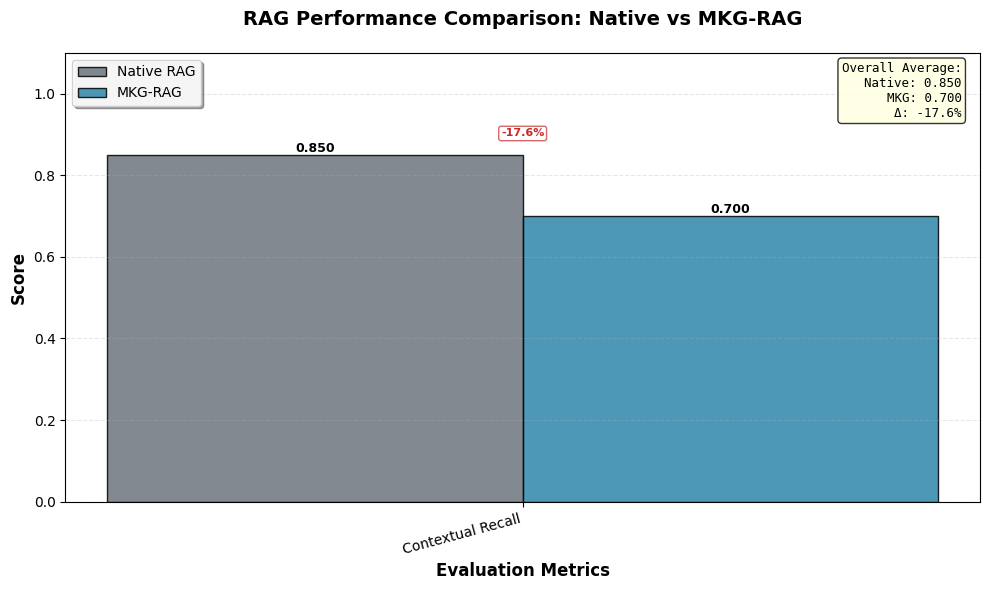


COMPREHENSIVE METRICS COMPARISON
Metric                         Native RAG      MKG-RAG         Improvement    
---------------------------------------------------------------------------
Contextual Recall              0.8500          0.7000          -17.65%      ✗
---------------------------------------------------------------------------
AVERAGE                        0.8500          0.7000          -17.65%


In [65]:
native_metrics = {
    "Contextual Recall": 0.85,
    # "Contextual Precision": 0.92,
}
mkg_metrics = {
    "Contextual Recall": 0.7,
    # "Contextual Precision": 0.78,
}
plot_rag_comparison_metrics(native_metrics, mkg_metrics)

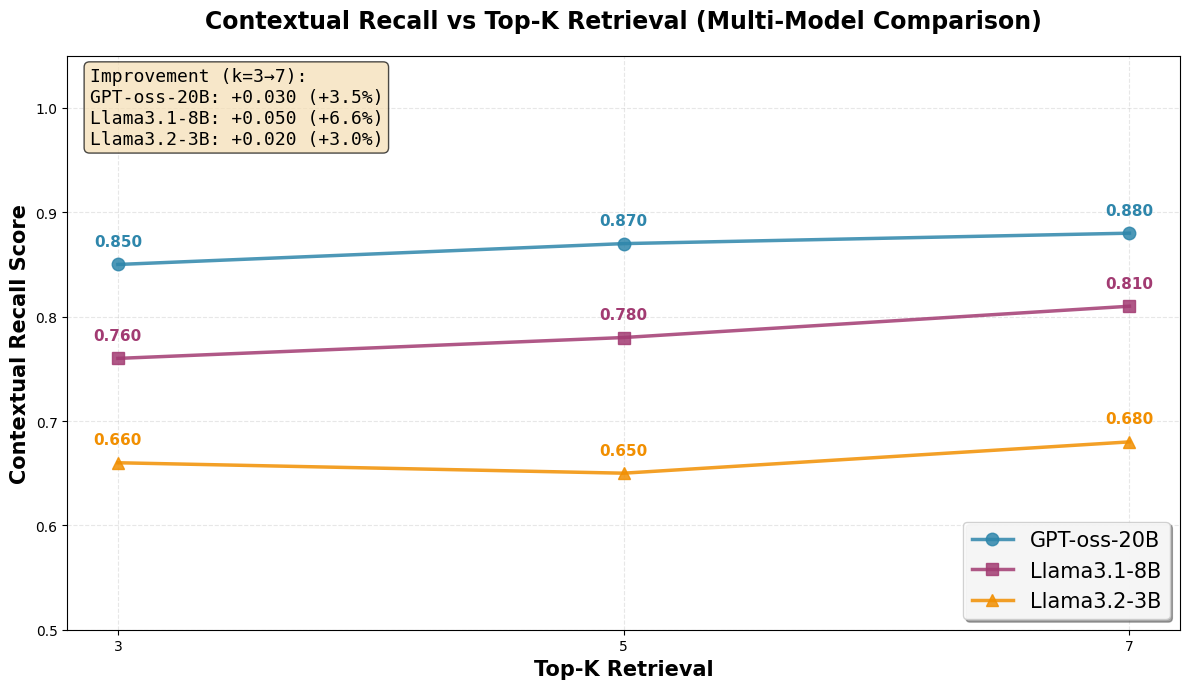


CONTEXTUAL RECALL COMPARISON - MULTI-MODEL
Top-K     GPT-oss-20B         Llama3.1-8B         Llama3.2-3B         
--------------------------------------------------------------------------------
3         0.8500              0.7600              0.6600              
5         0.8700              0.7800              0.6500              
7         0.8800              0.8100              0.6800              

IMPROVEMENT SUMMARY (First Top-K → Last Top-K)
--------------------------------------------------------------------------------
GPT-oss-20B          0.8500 → 0.8800  (Δ +0.0300, +3.5%)
Llama3.1-8B          0.7600 → 0.8100  (Δ +0.0500, +6.6%)
Llama3.2-3B          0.6600 → 0.6800  (Δ +0.0200, +3.0%)


In [55]:
# Example usage with multiple models:
results_multimodel = {
    "GPT-oss-20B": {3: 0.85, 5: 0.87, 7: 0.88},
    "Llama3.1-8B": {3: 0.76, 5: 0.78, 7: 0.81},
    "Llama3.2-3B": {3: 0.66, 5: 0.65, 7: 0.68},
}
plot_contextual_recall_topk_multimodel(results_multimodel)